### Tasks

* 1. Load any 3 sample images (your choice: selfies, food, cricket, or memes) and use OpenCV or PIL to resize each to 224x224 pixels, saving the resized versions in a new folder.

In [1]:
import os
from PIL import Image

In [2]:
os.makedirs("Resizd_image", exist_ok=True)

In [3]:
image_paths = [
    "food.jpg",
    "Harry Potter.webp",
    "Cricket.avif"
]

In [4]:
for img_path in image_paths:
    img = Image.open(img_path)
    Resizd_image = img.resize((224, 224))

    filename = os.path.basename(img_path)
    Resizd_image.save(os.path.join("Resizd_image", filename))
    
print("Images resized and saved Successfully")

Images resized and saved Successfully


* 2. Convert a colored image (choose any photo you like) to grayscale and then back to RGB using Python libraries. Display all three versions (original, grayscale, RGB) using matplotlib.

In [5]:
import cv2

In [6]:
import matplotlib.pyplot as plt

In [7]:
image = cv2.imread("Food.jpg")

In [8]:
original = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [9]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [10]:
rgb = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

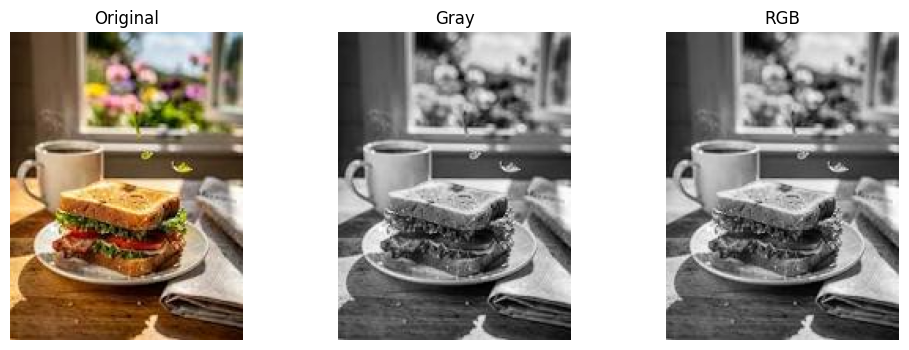

In [11]:
plt.figure(figsize=(12, 4))

plt.subplot(1,3,1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gray, cmap="gray")
plt.title("Gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(rgb)
plt.title("RGB")
plt.axis("off")

plt.show()

In [12]:
print(image.shape)  
print(gray.shape)    
print(rgb.shape)     

(196, 148, 3)
(196, 148)
(196, 148, 3)


* 3. Use Keras' ImageDataGenerator to apply random rotation and horizontal flip to an image of your choice (for example, a Zomato food pic or an IPL player). Generate and display 4 augmented versions.<br><br><em><strong>Hint:</strong> Set rotation_range and horizontal_flip in ImageDataGenerator, then use flow() or flow_from_directory().</em>

In [13]:
import numpy as np

In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

In [15]:
img = load_img("Cricket.avif", target_size=(224, 224))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

In [16]:
datagen = ImageDataGenerator(
    rotation_range=30,
    horizontal_flip=True
)

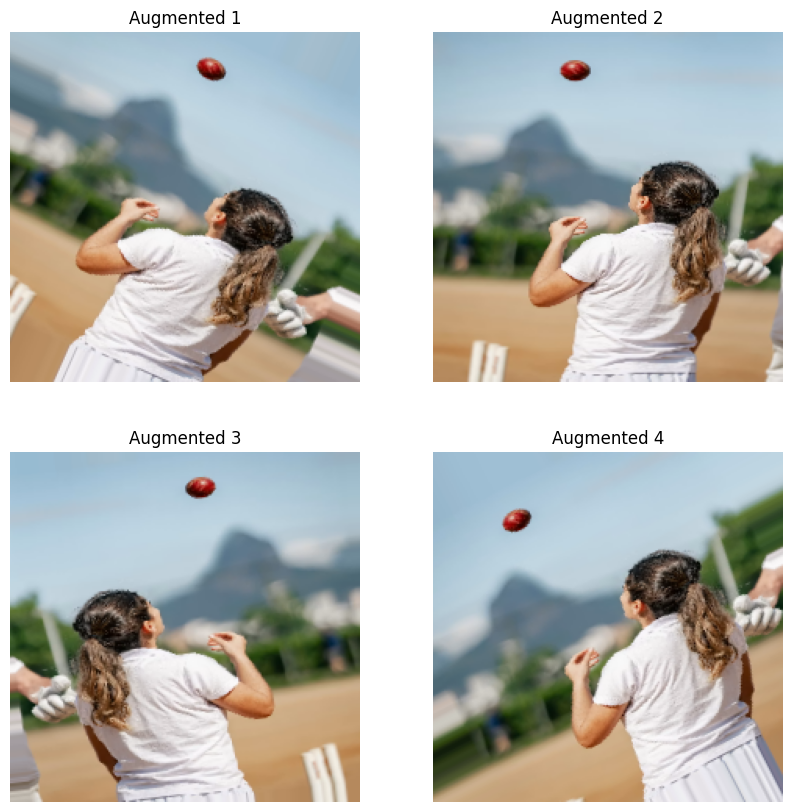

In [17]:
plt.figure(figsize=(10, 10))

i = 1
for batch in datagen.flow(img_array, batch_size=1):
    plt.subplot(2,2,i)
    plt.imshow(batch[0].astype("uint8"))
    plt.axis("off")
    plt.title(f"Augmented {i}")
    i += 1
    if i > 4:
        break

plt.show()

* 4. Write code to increase and decrease the brightness of a selfie or any image by 40% using ImageDataGenerator's brightness_range parameter. Show the original, brightened, and darkened images side by side.

In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

In [19]:
img = load_img("Cricket.avif", target_size=(224, 224))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

In [20]:
bright_gen = ImageDataGenerator(brightness_range=[1.4,1.4])
bright_img = next(bright_gen.flow(img_array, batch_size=1))[0].astype("uint8")

In [21]:
dark_gen = ImageDataGenerator(brightness_range=[0.6, 0.6])
dark_img = next(dark_gen.flow(img_array, batch_size=1))[0].astype("uint8")

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

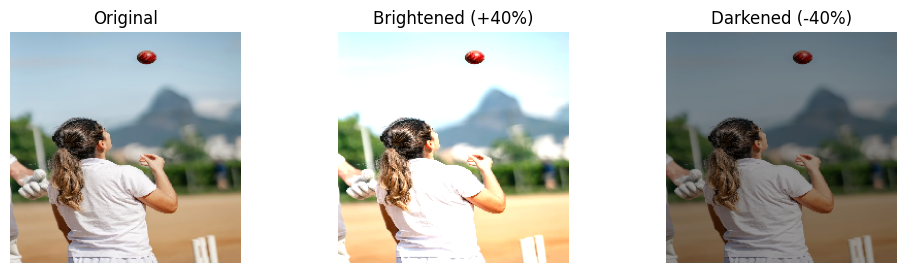

In [22]:
plt.figure(figsize=(12,3))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(bright_img)
plt.title("Brightened (+40%)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(dark_img)
plt.title("Darkened (-40%)")
plt.axis("off")

* 5. Pick any meme or cricket image and use ImageDataGenerator to apply a shear transformation. Explain in one line how the image changes visually after shearing.

In [23]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

In [24]:
img = load_img("Cricket.avif", target_size=(224,224))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

In [25]:
datagen = ImageDataGenerator(shear_range=50)
sheared = next(datagen.flow(img_array, batch_size=1))[0].astype("uint8")

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

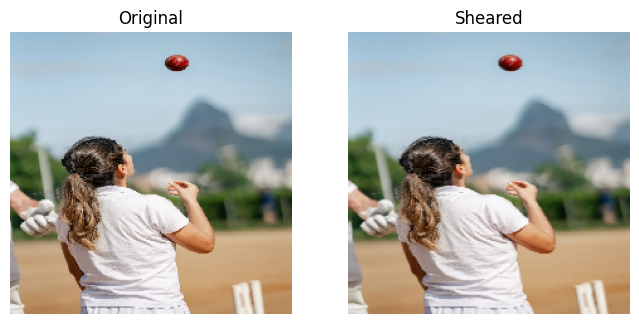

In [26]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(sheared)
plt.title("Sheared")
plt.axis("off")

The shear transformation slants the image by shifting pixels diagonally, making the object appear tilted without changing its overall content.